In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [18]:
df = pd.read_csv("titanic_dataset.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("titanic_dataset.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Q1. Create a Bar Chart to show the survival rate of passengers from each Embarked port.

#### X-axis: Embarked
#### Y-axis: Average of Survived
#### Add proper title and labels.
#### Identify which port has the highest survival rate.

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64


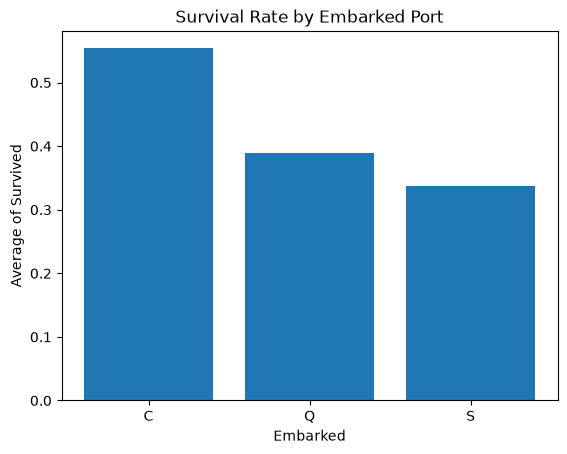

Highest survival port: C
Highest survival rate: 55.36%


In [11]:
# Calculate average survival rate
survival_rate = df.groupby("Embarked")["Survived"].mean()

print(survival_rate)

# Create bar chart
plt.bar(survival_rate.index, survival_rate.values)

plt.xlabel("Embarked")
plt.ylabel("Average of Survived")
plt.title("Survival Rate by Embarked Port")

plt.show()

# Find the port with highest survival rate
highest_port = survival_rate.idxmax()
highest_rate = survival_rate.max()

print("Highest survival port:", highest_port)
print(f"Highest survival rate: {highest_rate * 100:.2f}%")

### Q2. Create a new column FamilySize using:

#### FamilySize = SibSp + Parch + 1

#### Then create a Count Plot showing the number of passengers for each family-size category.

#### X-axis: FamilySize
#### Y-axis: Number of Passengers
#### Identify the most common family size.

   SibSp  Parch  FamilySize
0      1      0           2
1      1      0           2
2      0      0           1
3      1      0           2
4      0      0           1


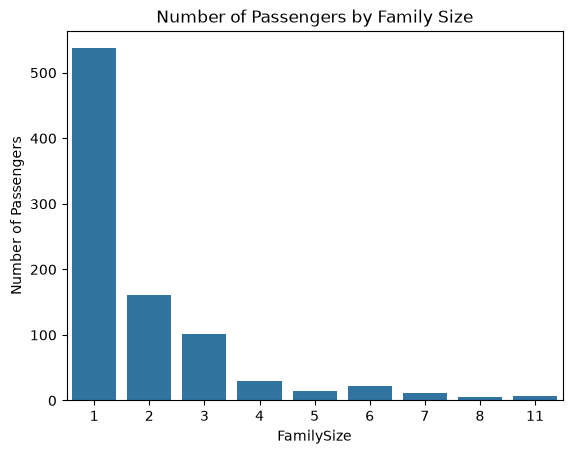

Most common family size: 1
Number of passengers: 537


In [12]:
# Create FamilySize column
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# Check the new column
print(df[["SibSp", "Parch", "FamilySize"]].head())

# Create count plot
sns.countplot(data=df, x="FamilySize")

plt.xlabel("FamilySize")
plt.ylabel("Number of Passengers")
plt.title("Number of Passengers by Family Size")

plt.show()

# Find most common family size
most_common_family = df["FamilySize"].value_counts().idxmax()
most_common_count = df["FamilySize"].value_counts().max()

print("Most common family size:", most_common_family)
print("Number of passengers:", most_common_count)

### Q3. Create a Box Plot to compare Fare across different Pclass, while separating passengers by Sex.

#### X-axis: Pclass
#### Y-axis: Fare
#### Use Sex as hue.
#### Identify which group paid the highest fares.

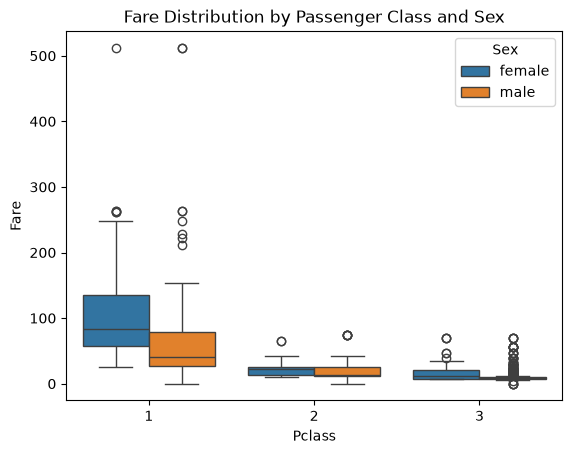

Highest fare:
Pclass           1
Sex         female
Fare      512.3292
Name: 258, dtype: object

Maximum fare by Pclass and Sex:
Pclass  Sex   
1       female    512.3292
        male      512.3292
2       female     65.0000
        male       73.5000
3       female     69.5500
        male       69.5500
Name: Fare, dtype: float64


In [13]:
# Create box plot
sns.boxplot(
    data=df,
    x="Pclass",
    y="Fare",
    hue="Sex"
)

plt.xlabel("Pclass")
plt.ylabel("Fare")
plt.title("Fare Distribution by Passenger Class and Sex")

plt.show()

# Find the passenger with highest fare
highest_fare = df.loc[df["Fare"].idxmax()]

print("Highest fare:")
print(highest_fare[["Pclass", "Sex", "Fare"]])

# Maximum fare for each Pclass and Sex
print("\nMaximum fare by Pclass and Sex:")
print(df.groupby(["Pclass", "Sex"])["Fare"].max())

### Q4. Using the FamilySize column created in Q2, create a Line Plot showing the average survival rate for each family size.

#### X-axis: FamilySize
#### Y-axis: Survival Rate
#### Add markers to the line.
#### Identify the family size with the highest survival rate.

FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64


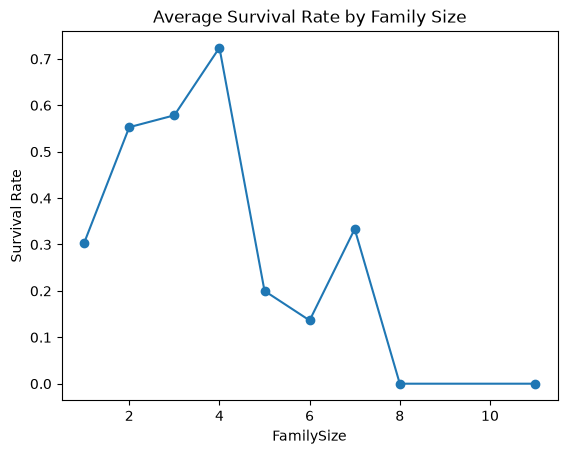

Family size with highest survival rate: 4
Highest survival rate: 72.41%


In [14]:
# Calculate average survival rate by FamilySize
family_survival = df.groupby("FamilySize")["Survived"].mean()

print(family_survival)

# Create line plot
plt.plot(
    family_survival.index,
    family_survival.values,
    marker="o"
)

plt.xlabel("FamilySize")
plt.ylabel("Survival Rate")
plt.title("Average Survival Rate by Family Size")

plt.show()

# Find family size with highest survival rate
highest_family = family_survival.idxmax()
highest_family_rate = family_survival.max()

print("Family size with highest survival rate:", highest_family)
print(f"Highest survival rate: {highest_family_rate * 100:.2f}%")

### Q5.Passenger Class & Gender Survival Comparison
#### Create a stacked bar chart showing the number of Survived and Not Survived passengers for each combination of Pclass and Sex.

Survived         0   1
Pclass Sex            
1      female    3  91
       male     77  45
2      female    6  70
       male     91  17
3      female   72  72
       male    300  47
               Not Survived  Survived
Pclass Sex                           
1      female             3        91
       male              77        45
2      female             6        70
       male              91        17
3      female            72        72
       male             300        47


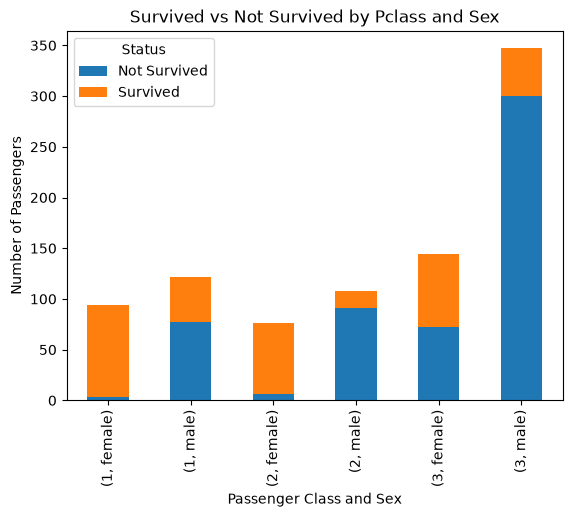

In [15]:
# Create cross-tabulation
survival_table = pd.crosstab(
    [df["Pclass"], df["Sex"]],
    df["Survived"]
)

print(survival_table)

# Rename columns
survival_table.columns = ["Not Survived", "Survived"]

print(survival_table)

# Create stacked bar chart
survival_table.plot(
    kind="bar",
    stacked=True
)

plt.xlabel("Passenger Class and Sex")
plt.ylabel("Number of Passengers")
plt.title("Survived vs Not Survived by Pclass and Sex")

plt.legend(title="Status")

plt.show()